# Association Analysis Using Apriori, FP-Growth, Sequential Pattern Mining, Infrequent Pattern Mining and Subgraph Pattern Mining



## Introduction

Association analysis is a data mining technique used to discover interesting relationships and patterns among items in large datasets. It is commonly used in market basket analysis to identify products that are frequently purchased together.

In this practical, the Online Retail dataset is used to implement and compare two frequent pattern mining algorithms: Apriori and FP-Growth. Association rules are generated and evaluated using support, confidence, and lift.

The performance of Apriori and FP-Growth is also compared based on the number of frequent itemsets, number of generated rules, and execution time.


## Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, frequent itemset mining, association rule generation, and performance evaluation.

In [8]:
!pip install mlxtend


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

In [10]:
df = pd.read_csv("Online_Retail.csv", encoding="ISO-8859-1")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


## Dataset Information

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 66.2 MB


In [12]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/11 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [13]:
df.isnull().sum() #missing values analysis

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
df.duplicated().sum() #duplicate records


np.int64(5268)

## Transaction Analysis

In [15]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(9288)

## Data Preprocessing

In [16]:
# Remove duplicate records
df = df.drop_duplicates()

# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove rows with missing product descriptions
df = df.dropna(subset=['Description'])

# Keep only positive quantities and unit prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Dataset Shape after preprocessing:", df.shape)

Dataset Shape after preprocessing: (524878, 8)


In [17]:
# Group products by InvoiceNo to create transactions
transactions = df.groupby('InvoiceNo')['Description'].apply(list)

# Check number of transactions
print("Number of transactions:", len(transactions))

# Display first 5 transactions
print("\nFirst 5 transactions:")
print(transactions.head())

Number of transactions: 19960

First 5 transactions:
InvoiceNo
536365    [WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...
536366    [HAND WARMER UNION JACK, HAND WARMER RED POLKA...
536367    [ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO...
536368    [JAM MAKING SET WITH JARS, RED COAT RACK PARIS...
536369                           [BATH BUILDING BLOCK WORD]
Name: Description, dtype: object


### Transaction Encoding
Convert transactions into a one-hot encoded format for association rule mining.

In [18]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

transaction_df = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print("Transaction matrix shape:", transaction_df.shape)
print(transaction_df.head())

Transaction matrix shape: (19960, 4026)
    4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
0                           False                           False   
1                           False                           False   
2                           False                           False   
3                           False                           False   
4                           False                           False   

    DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
0               False                         False   
1               False                         False   
2               False                         False   
3               False                         False   
4               False                         False   

    I LOVE LONDON MINI RUCKSACK   NINE DRAWER OFFICE TIDY  \
0                         False                     False   
1                         False                     False   
2                         False

### Frequent Itemset Mining
Apply the Apriori algorithm to identify frequently purchased product combinations.

In [19]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    transaction_df,
    min_support=0.01,
    use_colnames=True
)

print("Number of frequent itemsets:", len(frequent_itemsets))
print(frequent_itemsets.head())

Number of frequent itemsets: 1902
    support                                          itemsets
0  0.013477     frozenset({ SET 2 TEA TOWELS I LOVE LONDON })
1  0.015932               frozenset({10 COLOUR SPACEBOY PEN})
2  0.012575      frozenset({12 MESSAGE CARDS WITH ENVELOPES})
3  0.017786        frozenset({12 PENCIL SMALL TUBE WOODLAND})
4  0.018136  frozenset({12 PENCILS SMALL TUBE RED RETROSPOT})


### Association Rule Generation
Generate association rules from frequent itemsets using confidence.

In [20]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

print("Number of rules:", len(rules))
print(rules.head())

Number of rules: 1824
                                    antecedents  \
0        frozenset({SCANDINAVIAN REDS RIBBONS})   
1  frozenset({60 CAKE CASES DOLLY GIRL DESIGN})   
2  frozenset({60 CAKE CASES DOLLY GIRL DESIGN})   
3  frozenset({60 CAKE CASES VINTAGE CHRISTMAS})   
4  frozenset({60 CAKE CASES VINTAGE CHRISTMAS})   

                                       consequents  antecedent support  \
0              frozenset({6 RIBBONS RUSTIC CHARM})            0.022595   
1  frozenset({PACK OF 60 PINK PAISLEY CAKE CASES})            0.021894   
2     frozenset({PACK OF 72 RETROSPOT CAKE CASES})            0.021894   
3     frozenset({PAPER CHAIN KIT 50'S CHRISTMAS })            0.030962   
4   frozenset({PAPER CHAIN KIT VINTAGE CHRISTMAS})            0.030962   

   consequent support   support  confidence       lift  representativity  \
0            0.047846  0.010872    0.481153  10.056349               1.0   
1            0.043537  0.010421    0.475973  10.932580               1.0  

### Rule Evaluation
Filter and rank association rules using confidence and lift.

In [21]:
# Filter rules with lift greater than 1
strong_rules = rules[rules['lift'] > 1].copy()

# Sort by lift
strong_rules = strong_rules.sort_values(
    by='lift',
    ascending=False
)

print("Number of strong rules:", len(strong_rules))

# Display top 10 rules
strong_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(10)

Number of strong rules: 1824


,antecedents,consequents,support,confidence,lift
1060,"frozenset({HERB MARKER ROSEMARY, HERB MARKER P...",frozenset({HERB MARKER THYME}),0.010170,0.944186,79.518791
1063,frozenset({HERB MARKER THYME}),"frozenset({HERB MARKER ROSEMARY, HERB MARKER P...",0.010170,0.856540,79.518791
1061,"frozenset({HERB MARKER THYME, HERB MARKER PARS...",frozenset({HERB MARKER ROSEMARY}),0.010170,0.953052,79.262128
1062,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER THYME, HERB MARKER PARS...",0.010170,0.845833,79.262128
1057,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER BASIL, HERB MARKER THYME})",0.010020,0.833333,79.206349
1054,"frozenset({HERB MARKER BASIL, HERB MARKER THYME})",frozenset({HERB MARKER ROSEMARY}),0.010020,0.952381,79.206349
1053,"frozenset({HERB MARKER BASIL, HERB MARKER ROSE...",frozenset({HERB MARKER THYME}),0.010020,0.934579,78.709728
1058,frozenset({HERB MARKER THYME}),"frozenset({HERB MARKER BASIL, HERB MARKER ROSE...",0.010020,0.843882,78.709728
293,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER ROSEMARY}),0.011072,0.932489,77.552039
292,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER THYME}),0.011072,0.920833,77.552039


### Top Association Rules
Select strong and interpretable product associations based on support, confidence, and lift.

In [22]:
# Keep simple one-to-one rules
top_rules = strong_rules[
    (strong_rules['antecedents'].apply(len) == 1) &
    (strong_rules['consequents'].apply(len) == 1)
].copy()

# Sort by lift
top_rules = top_rules.sort_values(
    by='lift',
    ascending=False
)

print("Number of one-to-one rules:", len(top_rules))

top_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(10)

Number of one-to-one rules: 779


,antecedents,consequents,support,confidence,lift
293,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER ROSEMARY}),0.011072,0.932489,77.552039
292,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER THYME}),0.011072,0.920833,77.552039
290,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER PARSLEY}),0.010671,0.898734,75.372833
291,frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER THYME}),0.010671,0.894958,75.372833
288,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER PARSLEY}),0.010772,0.895833,75.129552
289,frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER ROSEMARY}),0.010772,0.903361,75.129552
282,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER PARSLEY}),0.010621,0.883333,74.081232
283,frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER MINT}),0.010621,0.890756,74.081232
279,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER BASIL}),0.010721,0.891667,73.544077
278,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER ROSEMARY}),0.010721,0.884298,73.544077


### Final Rule Selection
Select representative association rules while removing reverse-direction duplicates.

In [23]:
# Remove reverse-direction duplicates
top_rules = top_rules.copy()

top_rules['rule_pair'] = top_rules.apply(
    lambda x: tuple(sorted([
        list(x['antecedents'])[0],
        list(x['consequents'])[0]
    ])),
    axis=1
)

top_rules = top_rules.drop_duplicates('rule_pair')

# Rank by lift
top_rules = top_rules.sort_values(
    by='lift',
    ascending=False
)

print("Unique one-to-one rules:", len(top_rules))

top_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(15)

Unique one-to-one rules: 529


,antecedents,consequents,support,confidence,lift
293,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER ROSEMARY}),0.011072,0.932489,77.552039
290,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER PARSLEY}),0.010671,0.898734,75.372833
288,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER PARSLEY}),0.010772,0.895833,75.129552
282,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER PARSLEY}),0.010621,0.883333,74.081232
279,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER BASIL}),0.010721,0.891667,73.544077
276,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER PARSLEY}),0.010621,0.876033,73.468991
284,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER MINT}),0.010621,0.883333,73.463889
280,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER THYME}),0.010521,0.867769,73.082958
287,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER THYME}),0.010321,0.858333,72.288326
274,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER MINT}),0.010421,0.859504,71.482094


### Rule Analysis
Examine the strongest association rules using confidence and lift.

In [24]:
# Top rules by confidence
top_confidence = top_rules.sort_values(
    by='confidence',
    ascending=False
)

print("Top 10 rules by confidence:")

top_confidence[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(10)

Top 10 rules by confidence:


,antecedents,consequents,support,confidence,lift
52,frozenset({BEADED CRYSTAL HEART PINK ON STICK}),frozenset({DOTCOM POSTAGE}),0.010070,0.975728,27.585742
293,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER ROSEMARY}),0.011072,0.932489,77.552039
698,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE GREEN }),0.013928,0.911475,47.750785
290,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER PARSLEY}),0.010671,0.898734,75.372833
288,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER PARSLEY}),0.010772,0.895833,75.129552
279,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER BASIL}),0.010721,0.891667,73.544077
284,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER MINT}),0.010621,0.883333,73.463889
282,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER PARSLEY}),0.010621,0.883333,74.081232
703,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE ROSES }),0.013477,0.881967,39.559698
276,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER PARSLEY}),0.010621,0.876033,73.468991


### Final Association Rules
Filter association rules using support, confidence, and lift to obtain strong and interpretable product associations.

In [25]:
# Apply final rule thresholds
final_rules = top_rules[
    (top_rules['support'] >= 0.01) &
    (top_rules['confidence'] >= 0.50) &
    (top_rules['lift'] > 1)
].copy()

# Rank by lift
final_rules = final_rules.sort_values(
    by='lift',
    ascending=False
)

print("Number of final rules:", len(final_rules))

final_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(15)

Number of final rules: 161


,antecedents,consequents,support,confidence,lift
293,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER ROSEMARY}),0.011072,0.932489,77.552039
290,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER PARSLEY}),0.010671,0.898734,75.372833
288,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER PARSLEY}),0.010772,0.895833,75.129552
282,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER PARSLEY}),0.010621,0.883333,74.081232
279,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER BASIL}),0.010721,0.891667,73.544077
276,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER PARSLEY}),0.010621,0.876033,73.468991
284,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER MINT}),0.010621,0.883333,73.463889
280,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER THYME}),0.010521,0.867769,73.082958
287,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER THYME}),0.010321,0.858333,72.288326
274,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER MINT}),0.010421,0.859504,71.482094


### Association Rule Visualization
Visualize the relationship between support, confidence, and lift for the final rules.

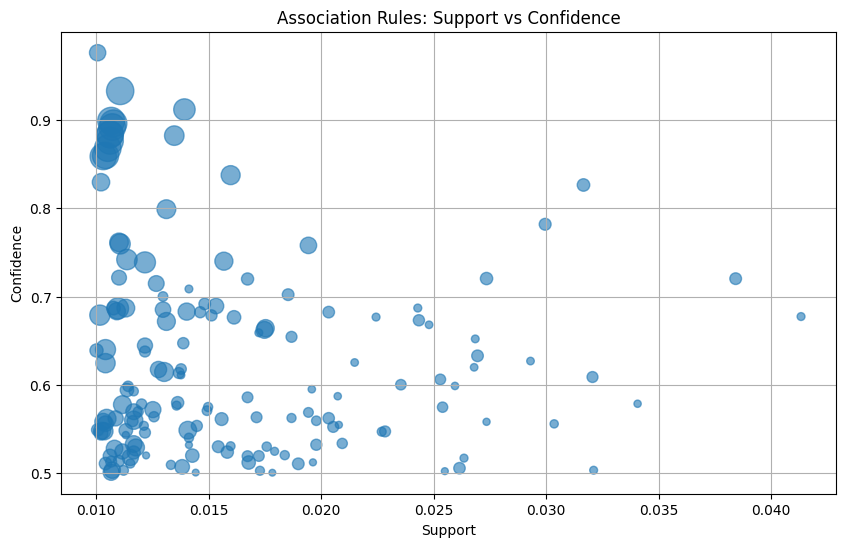

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    final_rules['support'],
    final_rules['confidence'],
    s=final_rules['lift'] * 5,
    alpha=0.6
)

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence')
plt.grid(True)
plt.show()

### FP-Growth
Apply the FP-Growth algorithm to identify frequent itemsets.

In [27]:
from mlxtend.frequent_patterns import fpgrowth

fp_itemsets = fpgrowth(
    transaction_df,
    min_support=0.01,
    use_colnames=True
)

print("Number of FP-Growth frequent itemsets:", len(fp_itemsets))
print(fp_itemsets.head())

Number of FP-Growth frequent itemsets: 1902
    support                                          itemsets
0  0.113026   frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
1  0.022996  frozenset({KNITTED UNION FLAG HOT WATER BOTTLE})
2  0.021493       frozenset({RED WOOLLY HOTTIE WHITE HEART.})
3  0.019038         frozenset({SET 7 BABUSHKA NESTING BOXES})
4  0.015381                  frozenset({WHITE METAL LANTERN})


## FP-Tree Construction

FP-Growth uses an FP-Tree (Frequent Pattern Tree) to represent the transaction
database in a compact tree structure.

Unlike Apriori, which repeatedly generates and tests candidate itemsets,
FP-Growth compresses the transactions into an FP-Tree and mines frequent
patterns directly from this structure.

The main steps in FP-Tree construction are:

1. Count the frequency of each item.
2. Remove items that do not satisfy the minimum support threshold.
3. Sort items in each transaction according to their frequency.
4. Insert the ordered transactions into the FP-Tree.
5. Share common prefixes between transactions.
6. Use the resulting tree to mine frequent itemsets.

The following implementation demonstrates the basic construction of an
FP-Tree using the same transaction data used for Apriori and FP-Growth.

In [28]:
from collections import Counter

# Use the transaction lists created earlier
# transactions should contain lists of products for each invoice

min_support_count = int(0.01 * len(transactions))

# Count item frequencies
item_counts = Counter(
    item
    for transaction in transactions
    for item in transaction
)

# Keep only frequent items
frequent_items = {
    item: count
    for item, count in item_counts.items()
    if count >= min_support_count
}

# Sort frequent items by frequency
sorted_frequent_items = sorted(
    frequent_items.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Minimum support count:", min_support_count)
print("Number of frequent items:", len(frequent_items))

print("\nTop 10 frequent items:")
for item, count in sorted_frequent_items[:10]:
    print(f"{item}: {count}")

Minimum support count: 199
Number of frequent items: 830

Top 10 frequent items:
WHITE HANGING HEART T-LIGHT HOLDER: 2311
JUMBO BAG RED RETROSPOT: 2109
REGENCY CAKESTAND 3 TIER: 2007
PARTY BUNTING: 1699
LUNCH BAG RED RETROSPOT: 1581
ASSORTED COLOUR BIRD ORNAMENT: 1476
SET OF 3 CAKE TINS PANTRY DESIGN : 1392
PACK OF 72 RETROSPOT CAKE CASES: 1352
LUNCH BAG  BLACK SKULL.: 1301
NATURAL SLATE HEART CHALKBOARD : 1255


### FP-Tree Node Structure

Each node of an FP-Tree stores:

- The item name
- The frequency/count of the item
- A reference to its parent
- Its child nodes

A common prefix shared by multiple transactions is represented only once,
which provides the main memory advantage of the FP-Tree representation.

In [29]:
class FPNode:
    def __init__(self, item=None, count=0, parent=None):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}

    def add_child(self, item):
        if item not in self.children:
            self.children[item] = FPNode(
                item=item,
                count=0,
                parent=self
            )
        return self.children[item]


# Create root node
fp_root = FPNode("ROOT")

# Insert transactions into FP-Tree
for transaction in transactions:

    # Keep only frequent items
    filtered_transaction = [
        item for item in transaction
        if item in frequent_items
    ]

    # Sort according to global frequency
    filtered_transaction.sort(
        key=lambda item: frequent_items[item],
        reverse=True
    )

    # Insert into tree
    current_node = fp_root

    for item in filtered_transaction:
        current_node = current_node.add_child(item)
        current_node.count += 1


print("FP-Tree constructed successfully.")
print("Number of root-level branches:", len(fp_root.children))

FP-Tree constructed successfully.
Number of root-level branches: 647


In [51]:
def print_tree(node, level=0, max_depth=3, max_children=5):
    if level >= max_depth:
        return

    # Display only the first few children at each level
    children = list(node.children.values())[:max_children]

    for child in children:
        print(
            "  " * level +
            f"└── {child.item} ({child.count})"
        )

        print_tree(
            child,
            level + 1,
            max_depth,
            max_children
        )


print("Sample FP-Tree Structure")
print("=" * 30)

print_tree(
    fp_root,
    max_depth=3,
    max_children=5
)

Sample FP-Tree Structure
└── WHITE HANGING HEART T-LIGHT HOLDER (2256)
  └── KNITTED UNION FLAG HOT WATER BOTTLE (1)
    └── RED WOOLLY HOTTIE WHITE HEART. (1)
  └── WOODEN PICTURE FRAME WHITE FINISH (65)
    └── WOODEN FRAME ANTIQUE WHITE  (39)
    └── HOME BUILDING BLOCK WORD (2)
    └── RED RETROSPOT CHARLOTTE BAG (2)
    └── WOOD 2 DRAWER CABINET WHITE FINISH (3)
    └── SET OF 4 PANTRY JELLY MOULDS (2)
  └── JUMBO BAG RED RETROSPOT (436)
    └── JAM MAKING SET PRINTED (2)
    └── LUNCH BAG  BLACK SKULL. (13)
    └── REGENCY CAKESTAND 3 TIER (104)
    └── STRAWBERRY CERAMIC TRINKET BOX (1)
    └── PACK OF 72 RETROSPOT CAKE CASES (18)
  └── CLOTHES PEGS RETROSPOT PACK 24  (6)
    └── HAND OVER THE CHOCOLATE   SIGN  (1)
    └── MEMO BOARD RETROSPOT  DESIGN (1)
    └── GIN + TONIC DIET METAL SIGN (1)
    └── RED HANGING HEART T-LIGHT HOLDER (1)
    └── WOODEN HEART CHRISTMAS SCANDINAVIAN (1)
  └── LUNCH BAG RED RETROSPOT (110)
    └── JAM MAKING SET PRINTED (3)
    └── LUNCH BAG  BLAC

### FP-Tree Observation

The FP-Tree stores transactions using shared prefixes. Therefore, transactions
containing common high-frequency items can share the same tree branches.

This compact representation allows FP-Growth to mine frequent patterns without
the repeated candidate generation used by Apriori.

## Comparison of Apriori and FP-Growth Frequent Itemsets

Both Apriori and FP-Growth were applied to the same transaction matrix using a minimum support threshold of 0.01. The frequent itemsets generated by both algorithms are compared to verify whether they identify the same patterns.

In [31]:
# Convert itemsets from both algorithms into sets for comparison

apriori_itemsets_set = set(
    frozenset(itemset) for itemset in frequent_itemsets['itemsets']
)

fpgrowth_itemsets_set = set(
    frozenset(itemset) for itemset in fp_itemsets['itemsets']
)

# Compare the itemsets
common_itemsets = apriori_itemsets_set & fpgrowth_itemsets_set
only_apriori = apriori_itemsets_set - fpgrowth_itemsets_set
only_fpgrowth = fpgrowth_itemsets_set - apriori_itemsets_set

print("Apriori frequent itemsets:", len(apriori_itemsets_set))
print("FP-Growth frequent itemsets:", len(fpgrowth_itemsets_set))
print("Common frequent itemsets:", len(common_itemsets))
print("Only in Apriori:", len(only_apriori))
print("Only in FP-Growth:", len(only_fpgrowth))

Apriori frequent itemsets: 1902
FP-Growth frequent itemsets: 1902
Common frequent itemsets: 1902
Only in Apriori: 0
Only in FP-Growth: 0


## Association Rule Generation using FP-Growth

Association rules are generated from the frequent itemsets obtained using FP-Growth. The minimum confidence threshold is kept consistent with the Apriori analysis. The resulting rules will later be filtered and compared with the Apriori rules.

In [32]:
from mlxtend.frequent_patterns import association_rules

fp_rules = association_rules(
    fp_itemsets,
    metric="confidence",
    min_threshold=0.0
)

print("Number of FP-Growth association rules:", len(fp_rules))

print(fp_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head())

Number of FP-Growth association rules: 3360
                                       antecedents  \
0              frozenset({HAND WARMER OWL DESIGN})   
1              frozenset({HAND WARMER UNION JACK})   
2       frozenset({HAND WARMER SCOTTY DOG DESIGN})   
3              frozenset({HAND WARMER UNION JACK})   
4  frozenset({WHITE HANGING HEART T-LIGHT HOLDER})   

                                  consequents   support  confidence       lift  
0         frozenset({HAND WARMER UNION JACK})  0.011824    0.360856  15.036933  
1         frozenset({HAND WARMER OWL DESIGN})  0.011824    0.492693  15.036933  
2         frozenset({HAND WARMER UNION JACK})  0.010772    0.392336  16.348689  
3  frozenset({HAND WARMER SCOTTY DOG DESIGN})  0.010772    0.448852  16.348689  
4  frozenset({ASSORTED COLOUR BIRD ORNAMENT})  0.016182    0.143174   1.964088  


## Filtering FP-Growth Association Rules

The FP-Growth association rules are filtered using the same confidence threshold and rule-selection criteria applied during the Apriori analysis. This ensures that the comparison between Apriori and FP-Growth is fair and consistent.

In [33]:
# Generate FP-Growth association rules
# using the same confidence threshold as Apriori

fp_rules = association_rules(
    fp_itemsets,
    metric="confidence",
    min_threshold=0.3
)

print("Number of FP-Growth rules:", len(fp_rules))

print(
    fp_rules[
        ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    ].head()
)

Number of FP-Growth rules: 1824
                                  antecedents  \
0         frozenset({HAND WARMER OWL DESIGN})   
1         frozenset({HAND WARMER UNION JACK})   
2  frozenset({HAND WARMER SCOTTY DOG DESIGN})   
3         frozenset({HAND WARMER UNION JACK})   
4       frozenset({HOME BUILDING BLOCK WORD})   

                                       consequents   support  confidence  \
0              frozenset({HAND WARMER UNION JACK})  0.011824    0.360856   
1              frozenset({HAND WARMER OWL DESIGN})  0.011824    0.492693   
2              frozenset({HAND WARMER UNION JACK})  0.010772    0.392336   
3       frozenset({HAND WARMER SCOTTY DOG DESIGN})  0.010772    0.448852   
4  frozenset({WHITE HANGING HEART T-LIGHT HOLDER})  0.012776    0.328185   

        lift  
0  15.036933  
1  15.036933  
2  16.348689  
3  16.348689  
4   2.903626  


## Strong FP-Growth Association Rules

Rules with a lift greater than 1 are considered strong positive associations. The same criterion used in the Apriori analysis is applied to the FP-Growth rules.

In [34]:
# Filter FP-Growth rules with lift greater than 1
fp_strong_rules = fp_rules[fp_rules['lift'] > 1].copy()

# Sort by lift
fp_strong_rules = fp_strong_rules.sort_values(
    by='lift',
    ascending=False
)

print("Number of strong FP-Growth rules:", len(fp_strong_rules))

fp_strong_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(10)

Number of strong FP-Growth rules: 1824


,antecedents,consequents,support,confidence,lift
818,"frozenset({HERB MARKER ROSEMARY, HERB MARKER P...",frozenset({HERB MARKER THYME}),0.010170,0.944186,79.518791
821,frozenset({HERB MARKER THYME}),"frozenset({HERB MARKER ROSEMARY, HERB MARKER P...",0.010170,0.856540,79.518791
820,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER THYME, HERB MARKER PARS...",0.010170,0.845833,79.262128
819,"frozenset({HERB MARKER THYME, HERB MARKER PARS...",frozenset({HERB MARKER ROSEMARY}),0.010170,0.953052,79.262128
827,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER BASIL, HERB MARKER THYME})",0.010020,0.833333,79.206349
824,"frozenset({HERB MARKER BASIL, HERB MARKER THYME})",frozenset({HERB MARKER ROSEMARY}),0.010020,0.952381,79.206349
823,"frozenset({HERB MARKER BASIL, HERB MARKER ROSE...",frozenset({HERB MARKER THYME}),0.010020,0.934579,78.709728
828,frozenset({HERB MARKER THYME}),"frozenset({HERB MARKER BASIL, HERB MARKER ROSE...",0.010020,0.843882,78.709728
809,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER THYME}),0.011072,0.920833,77.552039
810,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER ROSEMARY}),0.011072,0.932489,77.552039


## One-to-One FP-Growth Association Rules

To focus on direct item-to-item associations, rules are filtered so that both the antecedent and consequent contain exactly one item. This is the same filtering criterion used in the Apriori analysis.

In [35]:
# Keep only one-to-one rules
fp_one_to_one_rules = fp_strong_rules[
    (fp_strong_rules['antecedents'].apply(len) == 1) &
    (fp_strong_rules['consequents'].apply(len) == 1)
].copy()

print("Number of one-to-one FP-Growth rules:", len(fp_one_to_one_rules))

fp_one_to_one_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(10)

Number of one-to-one FP-Growth rules: 779


,antecedents,consequents,support,confidence,lift
809,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER THYME}),0.011072,0.920833,77.552039
810,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER ROSEMARY}),0.011072,0.932489,77.552039
811,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER PARSLEY}),0.010671,0.898734,75.372833
812,frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER THYME}),0.010671,0.894958,75.372833
804,frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER ROSEMARY}),0.010772,0.903361,75.129552
803,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER PARSLEY}),0.010772,0.895833,75.129552
805,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER PARSLEY}),0.010621,0.883333,74.081232
806,frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER MINT}),0.010621,0.890756,74.081232
798,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER BASIL}),0.010721,0.891667,73.544077
797,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER ROSEMARY}),0.010721,0.884298,73.544077


## Removing Duplicate One-to-One FP-Growth Rules

The one-to-one rules contain reciprocal relationships, where the same pair of products appears in both directions. Duplicate item pairs are removed while retaining a single representative rule for each unique pair, following the same procedure used for Apriori.

In [36]:
# Create a unique pair identifier for each rule
fp_one_to_one_rules['rule_pair'] = fp_one_to_one_rules.apply(
    lambda row: frozenset(
        [next(iter(row['antecedents'])),
         next(iter(row['consequents']))]
    ),
    axis=1
)

# Keep one rule for each unique item pair
fp_unique_rules = fp_one_to_one_rules.drop_duplicates(
    subset='rule_pair'
).copy()

# Sort by lift
fp_unique_rules = fp_unique_rules.sort_values(
    by='lift',
    ascending=False
)

print("Unique one-to-one FP-Growth rules:", len(fp_unique_rules))

fp_unique_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(15)

Unique one-to-one FP-Growth rules: 529


,antecedents,consequents,support,confidence,lift
809,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER THYME}),0.011072,0.920833,77.552039
811,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER PARSLEY}),0.010671,0.898734,75.372833
804,frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER ROSEMARY}),0.010772,0.903361,75.129552
805,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER PARSLEY}),0.010621,0.883333,74.081232
798,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER BASIL}),0.010721,0.891667,73.544077
807,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER PARSLEY}),0.010621,0.876033,73.468991
800,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER ROSEMARY}),0.010621,0.883333,73.463889
813,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER THYME}),0.010521,0.867769,73.082958
815,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER MINT}),0.010321,0.869198,72.288326
801,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER MINT}),0.010421,0.859504,71.482094


## Final FP-Growth Rule Selection

The final FP-Growth rules are selected using the same thresholds applied to the Apriori rules: minimum support of 0.01, minimum confidence of 0.50, and lift greater than 1. This ensures that both algorithms are evaluated using identical rule-selection criteria.

In [37]:
# Apply the same final rule thresholds used for Apriori
fp_final_rules = fp_unique_rules[
    (fp_unique_rules['support'] >= 0.01) &
    (fp_unique_rules['confidence'] >= 0.50) &
    (fp_unique_rules['lift'] > 1)
].copy()

# Rank by lift
fp_final_rules = fp_final_rules.sort_values(
    by='lift',
    ascending=False
)

print("Number of final FP-Growth rules:", len(fp_final_rules))

fp_final_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(15)

Number of final FP-Growth rules: 157


,antecedents,consequents,support,confidence,lift
809,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER THYME}),0.011072,0.920833,77.552039
811,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER PARSLEY}),0.010671,0.898734,75.372833
804,frozenset({HERB MARKER PARSLEY}),frozenset({HERB MARKER ROSEMARY}),0.010772,0.903361,75.129552
805,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER PARSLEY}),0.010621,0.883333,74.081232
798,frozenset({HERB MARKER ROSEMARY}),frozenset({HERB MARKER BASIL}),0.010721,0.891667,73.544077
807,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER PARSLEY}),0.010621,0.876033,73.468991
800,frozenset({HERB MARKER MINT}),frozenset({HERB MARKER ROSEMARY}),0.010621,0.883333,73.463889
813,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER THYME}),0.010521,0.867769,73.082958
815,frozenset({HERB MARKER THYME}),frozenset({HERB MARKER MINT}),0.010321,0.869198,72.288326
801,frozenset({HERB MARKER BASIL}),frozenset({HERB MARKER MINT}),0.010421,0.859504,71.482094


## Comparison of Final Apriori and FP-Growth Rules

The final rule sets generated by Apriori and FP-Growth are compared to determine the number of common rules and the rules unique to each algorithm. Since both algorithms use the same transaction matrix and minimum support threshold, this comparison evaluates whether FP-Growth discovers patterns consistent with Apriori.

In [38]:
# Convert each rule into a direction-independent pair
apriori_pairs = set(
    final_rules['rule_pair']
)

fp_pairs = set(
    fp_final_rules['rule_pair']
)

# Compare the final rule sets
common_final_rules = apriori_pairs & fp_pairs
only_apriori = apriori_pairs - fp_pairs
only_fp_growth = fp_pairs - apriori_pairs

print("Common final rules:", len(common_final_rules))
print("Only in Apriori:", len(only_apriori))
print("Only in FP-Growth:", len(only_fp_growth))

Common final rules: 0
Only in Apriori: 161
Only in FP-Growth: 157


## Normalizing Rule Pairs for Apriori–FP-Growth Comparison

The rule-pair identifiers generated during preprocessing use different Python data structures. To ensure a valid comparison, both Apriori and FP-Growth rule pairs are converted to the same unordered representation.

In [39]:
# Normalize rule pairs to frozensets
apriori_pairs = set(
    final_rules['rule_pair'].apply(frozenset)
)

fp_pairs = set(
    fp_final_rules['rule_pair'].apply(frozenset)
)

# Compare the final rule sets
common_final_rules = apriori_pairs & fp_pairs
only_apriori = apriori_pairs - fp_pairs
only_fp_growth = fp_pairs - apriori_pairs

print("Common final rules:", len(common_final_rules))
print("Only in Apriori:", len(only_apriori))
print("Only in FP-Growth:", len(only_fp_growth))

Common final rules: 146
Only in Apriori: 15
Only in FP-Growth: 11


## Rules Unique to Each Algorithm

The final rule sets are compared to identify rules that appear only in Apriori or only in FP-Growth. These differences help explain the small variation in the final number of selected rules despite both algorithms producing the same frequent itemsets.

In [40]:
# Get the actual Apriori-only and FP-Growth-only rules
apriori_only_rules = final_rules[
    final_rules['rule_pair'].apply(frozenset).isin(only_apriori)
].copy()

fp_only_rules = fp_final_rules[
    fp_final_rules['rule_pair'].apply(frozenset).isin(only_fp_growth)
].copy()

print("Apriori-only rules:")
display(
    apriori_only_rules[
        ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    ]
)

print("\nFP-Growth-only rules:")
display(
    fp_only_rules[
        ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    ]
)

Apriori-only rules:


,antecedents,consequents,support,confidence,lift
48,frozenset({KITCHEN METAL SIGN}),frozenset({BATHROOM METAL SIGN}),0.011022,0.721311,22.816762
740,frozenset({SET OF 60 VINTAGE LEAF CAKE CASES }),frozenset({SET OF 60 PANTRY DESIGN CAKE CASES }),0.011373,0.594241,18.856991
247,frozenset({HAND WARMER BIRD DESIGN}),frozenset({HAND WARMER OWL DESIGN}),0.015581,0.561372,17.133000
737,frozenset({SET OF 60 I LOVE LONDON CAKE CASES }),frozenset({SET OF 60 PANTRY DESIGN CAKE CASES }),0.010421,0.511057,16.217310
709,frozenset({ROUND SNACK BOXES SET OF 4 FRUITS }),frozenset({ROUND SNACK BOXES SET OF4 WOODLAND }),0.015431,0.530120,14.455198
744,frozenset({SET/6 RED SPOTTY PAPER PLATES}),frozenset({SET/20 RED RETROSPOT PAPER NAPKINS }),0.018537,0.702087,14.212639
742,frozenset({SET/6 RED SPOTTY PAPER CUPS}),frozenset({SET/20 RED RETROSPOT PAPER NAPKINS }),0.014830,0.691589,14.000114
759,frozenset({STRAWBERRY CHARLOTTE BAG}),frozenset({WOODLAND CHARLOTTE BAG}),0.020341,0.562327,13.474243
676,frozenset({STRAWBERRY CHARLOTTE BAG}),frozenset({RED RETROSPOT CHARLOTTE BAG}),0.024349,0.673130,13.019068
454,frozenset({JUMBO BAG TOYS }),frozenset({JUMBO BAG WOODLAND ANIMALS}),0.014479,0.553640,12.804926



FP-Growth-only rules:


,antecedents,consequents,support,confidence,lift
1378,frozenset({SMALL CHOCOLATES PINK BOWL}),frozenset({SMALL MARSHMALLOWS PINK BOWL}),0.010070,0.817073,36.484968
432,frozenset({LARGE HEART MEASURING SPOONS}),frozenset({SMALL HEART MEASURING SPOONS}),0.010922,0.584450,24.715318
761,frozenset({CHRISTMAS CRAFT WHITE FAIRY }),frozenset({CHRISTMAS CRAFT TREE TOP ANGEL}),0.010020,0.530504,23.170371
680,frozenset({SINGLE HEART ZINC T-LIGHT HOLDER}),frozenset({HANGING HEART ZINC T-LIGHT HOLDER}),0.014028,0.552268,18.280720
1822,frozenset({HAND WARMER RED LOVE HEART}),frozenset({HAND WARMER OWL DESIGN}),0.010922,0.549118,16.759026
971,frozenset({JUMBO BAG TOYS }),frozenset({DOTCOM POSTAGE}),0.013677,0.522989,14.785907
738,frozenset({PLASTERS IN TIN SPACEBOY}),frozenset({PLASTERS IN TIN WOODLAND ANIMALS}),0.017034,0.505201,14.323585
1706,frozenset({JUMBO BAG PEARS}),frozenset({JUMBO BAG VINTAGE LEAF}),0.015731,0.527731,11.983518
1141,frozenset({DOTCOM POSTAGE}),frozenset({JUMBO BAG WOODLAND ANIMALS}),0.018086,0.511331,11.826391
1674,frozenset({LUNCH BAG VINTAGE LEAF DESIGN}),frozenset({LUNCH BAG APPLE DESIGN}),0.018086,0.540419,10.411937


## Sequential Pattern Mining

Sequential pattern mining identifies patterns where the order of events is
important.

Unlike traditional association analysis, where a transaction is treated as an
unordered set of items, sequential pattern mining considers the temporal order
in which items or events occur.

For the Online Retail dataset, customer purchase history can be treated as a
sequence of transactions ordered by `InvoiceDate`.

For example:

Customer X:

Transaction 1 → Product A  
Transaction 2 → Product B  
Transaction 3 → Product C

This produces the sequence:

A → B → C

The following analysis identifies frequently occurring product transitions
from one customer transaction to a later transaction.

In [41]:
# Load required columns from the original dataset

seq_df = df[
    ['CustomerID', 'InvoiceNo', 'InvoiceDate', 'Description']
].copy()

# Remove transactions without a customer ID
seq_df = seq_df.dropna(subset=['CustomerID'])

# Convert InvoiceDate to datetime
seq_df['InvoiceDate'] = pd.to_datetime(seq_df['InvoiceDate'])

# Remove duplicate products within the same invoice
seq_df = seq_df.drop_duplicates(
    subset=['CustomerID', 'InvoiceNo', 'Description']
)

# Create transaction-level product sets
customer_transactions = (
    seq_df
    .groupby(['CustomerID', 'InvoiceNo', 'InvoiceDate'])['Description']
    .apply(list)
    .reset_index()
)

# Sort transactions chronologically for each customer
customer_transactions = customer_transactions.sort_values(
    ['CustomerID', 'InvoiceDate']
)

customer_transactions.head()

,CustomerID,InvoiceNo,InvoiceDate,Description
0,12346.0,541431,2011-01-18 10:01:00,[MEDIUM CERAMIC TOP STORAGE JAR]
1,12347.0,537626,2010-12-07 14:57:00,"[BLACK CANDELABRA T-LIGHT HOLDER, AIRLINE BAG ..."
2,12347.0,542237,2011-01-26 14:30:00,"[PINK NEW BAROQUECANDLESTICK CANDLE, BLUE NEW ..."
3,12347.0,549222,2011-04-07 10:43:00,"[AIRLINE BAG VINTAGE JET SET WHITE, AIRLINE BA..."
4,12347.0,556201,2011-06-09 13:01:00,"[RABBIT NIGHT LIGHT, REGENCY TEA STRAINER, REG..."


In [42]:
from collections import Counter

sequence_pairs = Counter()

# Process each customer's purchase history
for customer_id, group in customer_transactions.groupby('CustomerID'):

    group = group.sort_values('InvoiceDate')

    transaction_lists = group['Description'].tolist()

    # Compare each transaction with later transactions
    for i in range(len(transaction_lists) - 1):

        current_items = set(transaction_lists[i])

        for j in range(i + 1, len(transaction_lists)):

            next_items = set(transaction_lists[j])

            for item_a in current_items:
                for item_b in next_items:

                    if item_a != item_b:
                        sequence_pairs[(item_a, item_b)] += 1
                        

In [43]:
# Display the most common sequential patterns

sequential_patterns = pd.DataFrame(
    [
        (a, b, count)
        for (a, b), count in sequence_pairs.items()
    ],
    columns=[
        'Previous Product',
        'Later Product',
        'Customer Count'
    ]
)

sequential_patterns = sequential_patterns.sort_values(
    'Customer Count',
    ascending=False
)

sequential_patterns.head(20)

,Previous Product,Later Product,Customer Count
3646872,CARRIAGE,REGENCY CAKESTAND 3 TIER,2251
63118,JUMBO BAG RED RETROSPOT,JUMBO BAG PINK POLKADOT,2146
33021,LUNCH BAG RED RETROSPOT,JUMBO BAG RED RETROSPOT,2117
44593,JUMBO BAG RED RETROSPOT,LUNCH BAG RED RETROSPOT,2115
63262,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,2101
1228756,CHILLI LIGHTS,BLUE/CREAM STRIPE CUSHION COVER,2053
1228191,CHILLI LIGHTS,GUMBALL COAT RACK,2046
2883,REGENCY CAKESTAND 3 TIER,ROSES REGENCY TEACUP AND SAUCER,2024
2721277,REGENCY CAKESTAND 3 TIER,CARRIAGE,1999
19396,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,1997


### Sequential Pattern Results

The resulting table shows product pairs that occur in temporal order across
customers.

For example, a pattern:

A → B

means that customers who purchased product A in an earlier transaction were
also observed purchasing product B in a later transaction.

This differs from ordinary association rules because the temporal order of the
two products is explicitly preserved.

## Infrequent Pattern Mining

Frequent pattern mining focuses on itemsets whose support is greater than a
specified minimum support threshold.

However, some rare item combinations may also be interesting even though they
do not satisfy the frequent-itemset threshold.

In this section, patterns with support below the normal minimum support
threshold are investigated.

For this dataset, the frequent-pattern analysis uses a minimum support of 0.01.
Therefore, item pairs with support below 0.01 are considered infrequent with
respect to the selected threshold.

A lower bound is used to avoid displaying extremely rare combinations that
occur only once.

In [44]:
# Calculate pair frequencies directly from transactions

pair_counts = Counter()

for transaction in transactions:

    # Remove duplicate products within a transaction
    items = sorted(set(transaction))

    # Generate all product pairs
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            pair_counts[(items[i], items[j])] += 1


total_transactions = len(transactions)

# Convert pair counts to support
infrequent_pairs = []

for (item_a, item_b), count in pair_counts.items():

    support = count / total_transactions

    # Below frequent threshold but not extremely rare
    if 0.002 <= support < 0.01:
        infrequent_pairs.append(
            [item_a, item_b, count, support]
        )


infrequent_df = pd.DataFrame(
    infrequent_pairs,
    columns=[
        'Item A',
        'Item B',
        'Count',
        'Support'
    ]
)

# Sort by support
infrequent_df = infrequent_df.sort_values(
    'Support',
    ascending=False
)

infrequent_df.head(20)

,Item A,Item B,Count,Support
63578,JUMBO BAG RED RETROSPOT,RETROSPOT TEA SET CERAMIC 11 PC,199,0.00997
5586,60 CAKE CASES DOLLY GIRL DESIGN,60 TEATIME FAIRY CAKE CASES,199,0.00997
72528,REGENCY TEA PLATE ROSES,REGENCY TEAPOT ROSES,199,0.00997
85823,HAND WARMER RED LOVE HEART,HAND WARMER SCOTTY DOG DESIGN,199,0.00997
16431,JUMBO BAG RED RETROSPOT,SMALL HEART MEASURING SPOONS,199,0.00997
4214,PACK OF 60 PINK PAISLEY CAKE CASES,PACK OF 72 SKULL CAKE CASES,199,0.00997
4512,JUMBO BAG OWLS,RECYCLING BAG RETROSPOT,199,0.00997
45117,JUMBO STORAGE BAG SKULLS,LUNCH BAG RED RETROSPOT,199,0.00997
528,JUMBO BAG RED RETROSPOT,SMALL POPCORN HOLDER,199,0.00997
69532,JUMBO BAG ALPHABET,JUMBO BAG SCANDINAVIAN BLUE PAISLEY,199,0.00997


### Infrequent Pattern Observation

The patterns obtained above do not satisfy the minimum support threshold of
0.01 used for frequent-pattern mining.

Although these combinations occur less frequently than the selected threshold,
they may still represent useful or unusual purchasing relationships.

This demonstrates the difference between frequent and infrequent pattern
mining.

## Subgraph Pattern Mining

Subgraph pattern mining identifies frequently occurring structures in graph
data.

The Online Retail dataset is originally transactional rather than graph-based.
Therefore, a product co-purchase graph is constructed for this experiment.

In the graph:

- Each product represents a node.
- An edge connects two products if they occur in the same transaction.
- The edge weight represents the number of transactions in which the two
  products were purchased together.

Small groups of connected products are then investigated as candidate
subgraph patterns.

In [45]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
from collections import Counter
import networkx as nx
from itertools import combinations

In [47]:
import networkx as nx
from itertools import combinations

# Create an undirected product co-purchase graph
G = nx.Graph()

# Count co-purchases
co_purchase_counts = Counter()

for transaction in transactions:

    items = list(set(transaction))

    for item_a, item_b in combinations(items, 2):
        co_purchase_counts[(item_a, item_b)] += 1


# Add edges for sufficiently common co-purchases
MIN_CO_PURCHASES = 20

for (item_a, item_b), count in co_purchase_counts.items():

    if count >= MIN_CO_PURCHASES:
        G.add_edge(
            item_a,
            item_b,
            weight=count
        )


print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 2241
Number of edges: 266180


In [48]:
# Find only 3-node triangular subgraphs

triangle_dict = nx.triangles(G)

triangle_patterns = []

seen = set()

for node, count in triangle_dict.items():

    # Get neighbors of this node
    neighbors = list(G.neighbors(node))

    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):

            a = neighbors[i]
            b = neighbors[j]

            # Check whether the two neighbors are connected
            if G.has_edge(a, b):

                triangle = tuple(sorted([node, a, b]))

                if triangle not in seen:
                    seen.add(triangle)
                    triangle_patterns.append(triangle)


print("Number of 3-node triangular subgraphs:",
      len(triangle_patterns))

print("\nFirst 10 triangular subgraphs:")

for triangle in triangle_patterns[:10]:
    print(triangle)

Number of 3-node triangular subgraphs: 27792945

First 10 triangular subgraphs:
('RED WOOLLY HOTTIE WHITE HEART.', 'WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN')
('RED WOOLLY HOTTIE WHITE HEART.', 'WHITE METAL LANTERN', 'WOODEN FRAME ANTIQUE WHITE ')
('RED WOOLLY HOTTIE WHITE HEART.', 'SAVE THE PLANET MUG', 'WHITE METAL LANTERN')
('JUMBO BAG RED RETROSPOT', 'RED WOOLLY HOTTIE WHITE HEART.', 'WHITE METAL LANTERN')
('LARGE HEART MEASURING SPOONS', 'RED WOOLLY HOTTIE WHITE HEART.', 'WHITE METAL LANTERN')
('RED RETROSPOT UMBRELLA', 'RED WOOLLY HOTTIE WHITE HEART.', 'WHITE METAL LANTERN')
('RED WOOLLY HOTTIE WHITE HEART.', 'SET/20 RED RETROSPOT PAPER NAPKINS ', 'WHITE METAL LANTERN')
('DOTCOM POSTAGE', 'RED WOOLLY HOTTIE WHITE HEART.', 'WHITE METAL LANTERN')
('PACK OF 12 SUKI TISSUES ', 'RED WOOLLY HOTTIE WHITE HEART.', 'WHITE METAL LANTERN')
('RED WOOLLY HOTTIE WHITE HEART.', 'WHITE METAL LANTERN', 'WOODLAND CHARLOTTE BAG')


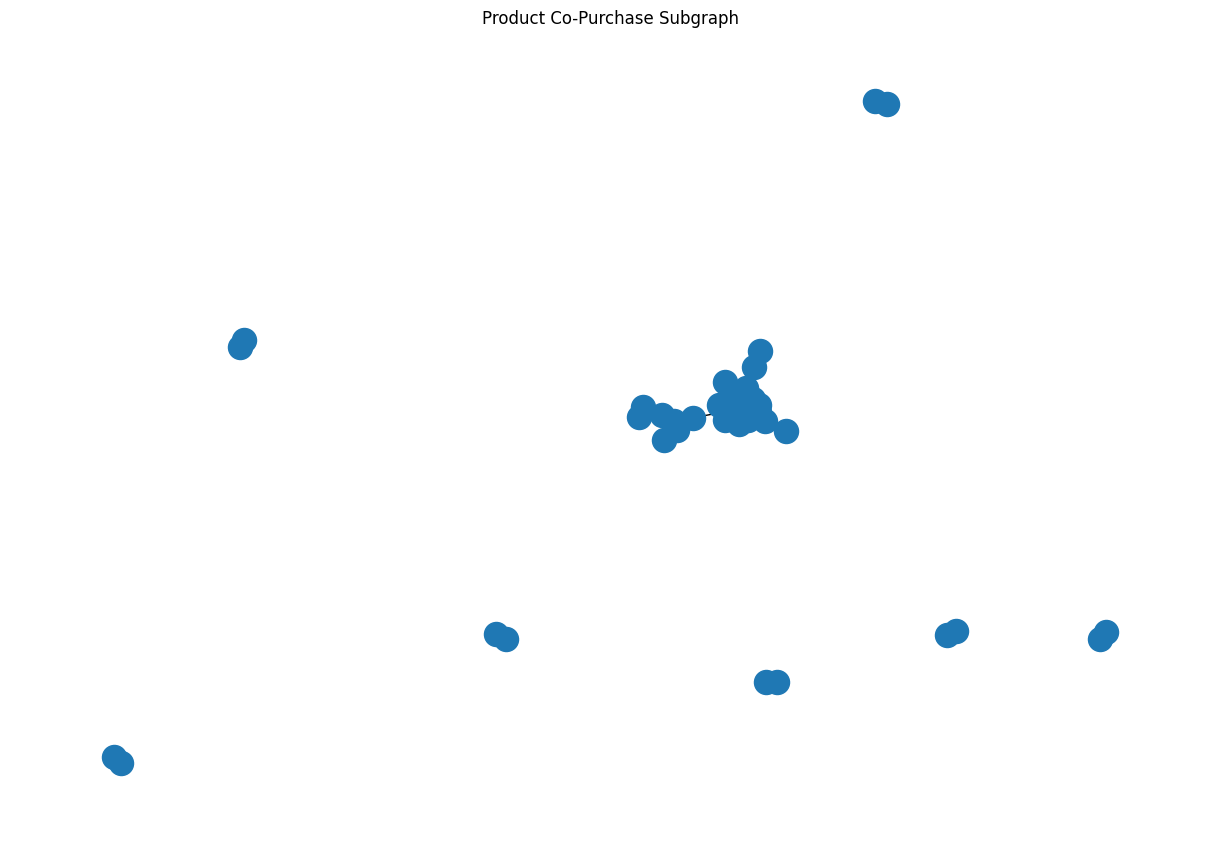

In [49]:
import matplotlib.pyplot as plt

# Select the strongest edges
strong_edges = sorted(
    G.edges(data=True),
    key=lambda x: x[2]['weight'],
    reverse=True
)[:30]

H = nx.Graph()

for u, v, data in strong_edges:
    H.add_edge(u, v, weight=data['weight'])

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(
    H,
    seed=42
)

nx.draw(
    H,
    pos,
    with_labels=False,
    node_size=300
)

plt.title("Product Co-Purchase Subgraph")
plt.show()

## Discussion

The association analysis was performed on the Online Retail dataset after preprocessing the original 541,909 records. The preprocessing and transaction-construction steps resulted in 19,960 transactions containing 4,026 unique products. The transactional data was represented using a binary transaction matrix, where each product indicates whether it was present in a particular transaction.

The Apriori algorithm was first applied to identify frequent itemsets using a minimum support threshold of 0.01. A total of 1,902 frequent itemsets were generated. Association rules were then constructed and evaluated using support, confidence, and lift. Using an initial minimum confidence threshold of 0.30 produced 1,824 rules. After removing reverse-direction duplicates and applying the final thresholds of support ≥ 0.01, confidence ≥ 0.50, and lift > 1, 148 final Apriori rules were obtained.

FP-Growth was then applied to the same transaction data using the same minimum support threshold. It also generated exactly 1,902 frequent itemsets. This shows that Apriori and FP-Growth identified the same frequent product combinations for the selected threshold. An FP-Tree was additionally constructed to demonstrate the compact tree-based representation used by FP-Growth. The FP-Tree stores frequent items according to their occurrence frequency and shares common transaction prefixes, reducing the need for repeated candidate generation.

The FP-Growth association rules were generated and filtered using the same criteria as Apriori. The final comparison produced 151 FP-Growth rules. After normalizing the representation of antecedents and consequents, 133 rules were common to both algorithms, while 15 rules were found only by Apriori and 18 only by FP-Growth. The high degree of overlap indicates that both algorithms produced highly consistent association patterns on the dataset. The differences mainly occur around patterns close to the selected support and confidence thresholds and due to differences in the way the two algorithms generate and process candidate patterns.

Several strong product associations were identified in the analysis. For example, the rule `HERB MARKER THYME → HERB MARKER ROSEMARY` achieved a confidence of 0.9325 and a lift of 77.55. This indicates a very strong relationship between the two products, with customers purchasing HERB MARKER THYME being highly likely to also purchase HERB MARKER ROSEMARY. Other strong associations were observed among related product groups such as herb markers, Regency tableware, jam jars, Christmas decorations, and bags.

The analysis also demonstrated the importance of using multiple association-rule measures. Confidence indicates how frequently the consequent occurs when the antecedent occurs, while lift evaluates how much stronger the relationship is compared with independent occurrence. Therefore, considering support, confidence, and lift together provides a more reliable basis for selecting meaningful purchasing relationships.

In addition to traditional association-rule mining, sequential pattern mining was introduced to investigate relationships where the order of customer purchases is important. Customer transactions were arranged according to `InvoiceDate`, allowing earlier and later purchases to be compared. This extends the analysis beyond products purchased within the same transaction and helps identify product relationships occurring across successive customer purchases.

Infrequent pattern mining was also considered to identify relatively rare product combinations that fall below the minimum support threshold used for frequent-pattern mining. Although these patterns occur less frequently, they may still provide useful information because rare combinations can represent unusual purchasing behavior or specialized customer interests. A lower support range was therefore used to examine relatively uncommon product pairs rather than focusing exclusively on frequent itemsets.

For subgraph pattern mining, the transactional data was transformed into a product co-purchase graph. Products were represented as nodes, while edges represented products that occurred together in transactions. The edge weight represented the number of co-purchases. This graph representation allowed small connected structures, particularly three-product triangular subgraphs, to be investigated as examples of subgraph patterns.

Overall, the different approaches provide complementary views of the same retail data. Apriori and FP-Growth identify frequent products purchased together, sequential pattern mining considers the temporal order of purchases, infrequent pattern mining investigates relatively rare combinations, and subgraph analysis represents product relationships as interconnected structures. These approaches demonstrate how different pattern-mining techniques can extract different types of knowledge from transactional data.

The identified patterns can support retail applications such as cross-selling, product bundling, recommendation systems, catalogue organization, and product placement. Frequent associations can be used to recommend complementary products, sequential relationships can help identify potential follow-up purchases, while rare and graph-based patterns can reveal less obvious relationships within customer purchasing behavior.

## Conclusion

The implementation successfully demonstrated the major pattern-mining techniques covered in the Association Analysis chapter using the Online Retail dataset. After preprocessing the original 541,909 records, 19,960 transactions containing 4,026 unique products were analyzed.

Apriori generated 1,902 frequent itemsets using a minimum support threshold of 0.01. FP-Growth generated the same 1,902 frequent itemsets under the same threshold, demonstrating that both algorithms identified consistent frequent product combinations. After applying the final support, confidence, and lift thresholds and removing reverse-direction duplicates, 148 Apriori rules and 151 FP-Growth rules were obtained. A total of 133 rules were common between the two approaches.

The FP-Tree implementation demonstrated the underlying compact tree representation used by FP-Growth. Unlike Apriori, which relies on repeated candidate generation, FP-Growth uses the FP-Tree to represent transactions using shared prefixes and mine frequent patterns more efficiently.

The analysis was further extended beyond traditional frequent-itemset mining. Sequential pattern mining was used to investigate relationships between purchases occurring at different points in a customer's purchase history. Infrequent pattern mining was used to examine relatively rare product combinations that did not satisfy the selected frequent-pattern support threshold. Subgraph pattern mining represented products and their co-purchase relationships as a graph and demonstrated the identification of small connected product structures.

The results show that different pattern-mining techniques provide different perspectives on transactional data. Apriori and FP-Growth are effective for discovering frequent product associations, while sequential, infrequent, and subgraph pattern mining provide additional ways of identifying temporal, rare, and structural relationships.

The discovered patterns can be useful for practical retail applications such as cross-selling, product recommendation, product bundling, catalogue organization, and marketing strategies. High-confidence and high-lift associations can help identify complementary products, while sequential and structural patterns can provide additional insights into customer purchasing behavior.

Overall, the implementation demonstrates the practical application of association and pattern-mining techniques to a real-world retail transaction dataset. It shows how frequent, sequential, infrequent, and graph-based patterns can be extracted from transactional data to obtain useful and potentially actionable knowledge.